# Fair Shapley Value Calculation for synthetic datasets

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:

import warnings
warnings.filterwarnings("ignore")

In [7]:
import numpy as np
import sklearn.datasets as dt
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import seaborn as sns


from fairSV.fair_shapley import FairShapley
import aif360.sklearn.metrics as aifmet

from sklearn.manifold import TSNE

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier


from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.inspection import DecisionBoundaryDisplay

from scipy.stats import multivariate_normal

FOLDER_PLOTS = 'figs/SV_plots/'

## Tiny Example

In [8]:
X_train = np.array([[0,1],
                    [1,1],
                    [1,0],
                    [2,1]
                    ])

y_train = np.array([1,1,0,1])

X_test =np.array([[1.7,0.7],
                 [0.4,1],
                 [1,0.4]])
                 
y_test = np.array([1,0,1])


<Figure size 640x480 with 0 Axes>

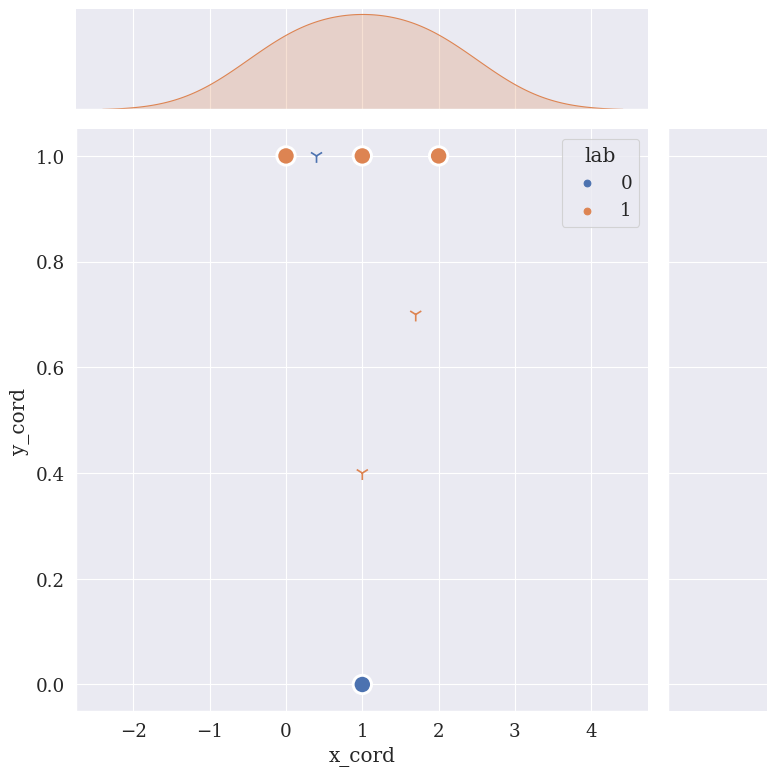

In [9]:
fsv_tiny = FairShapley(X_train, y_train, X_test, y_test, show_plot=True)
fsv_tiny.plot_data_sns(size=700, test=True, size_test=100)

Finding best k: 100%|██████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 1013.93it/s]


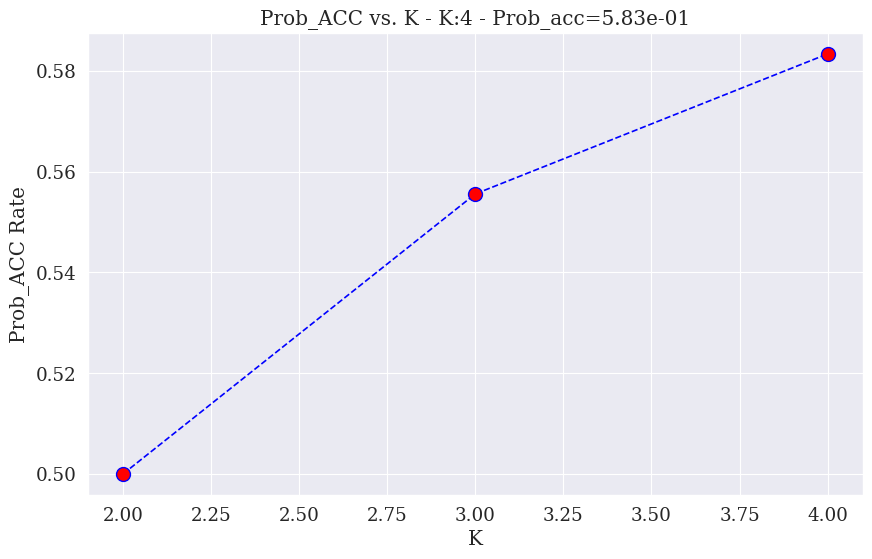

In [10]:
k,prob_acc,probs=fsv_tiny.get_best_K()

In [11]:
SV_tiny = fsv_tiny.get_SV_matrix(K=k)

Calculating SV Matrix: 100%|█████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


In [12]:
clfs,_ = fsv_tiny.do_knn(k=4)
pd.DataFrame(clfs).T

,acc,TPR,TNR,FPR,FNR,EqualOp,EqualOp_bounded,Max_acc_disp_diff,Max_acc_disp_log,Max_acc_disp_ratio,AUC
def,0.666667,1.0,0.0,1.0,0.0,0.0,0.5,1.0,inf,inf,0.5
opt_0.75,0.666667,1.0,0.0,1.0,0.0,0.0,0.5,1.0,inf,inf,0.5
indep,0.583333,0.75,0.25,0.75,0.25,0.0,0.5,0.5,1.584963,2.0,0.5


In [13]:
fsv_tiny.get_sv_summary()

,sum
sv_acc,0.583333
sv_eop,0.000000
sv_eop_bounded,0.500000
sv_fnr,0.250000
sv_fpr,0.750000
sv_max_acc_disp_diff,0.500000
sv_max_acc_disp_log,-inf
sv_tnr,0.250000
sv_tp_diff,1.000000
sv_tpr,0.750000


<Figure size 640x480 with 0 Axes>

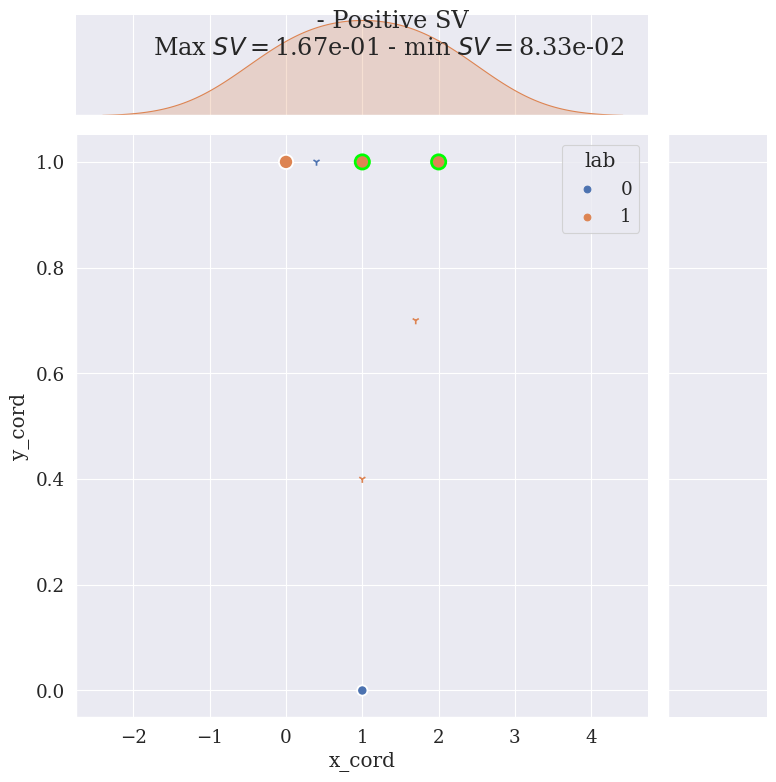

In [14]:
fsv_tiny.plot_data_sns(size='sv_pos',test=True)

<Figure size 640x480 with 0 Axes>

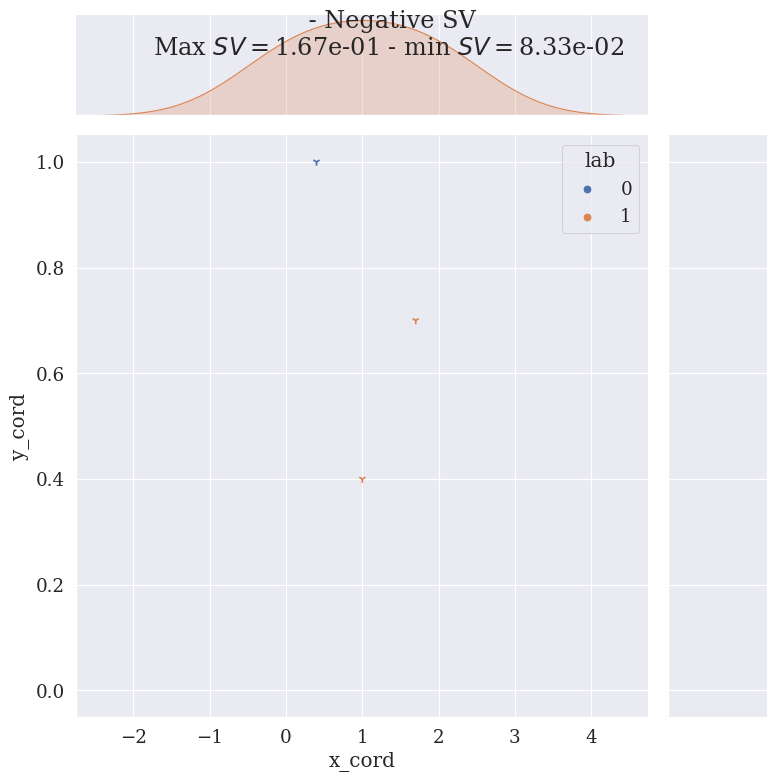

In [15]:
fsv_tiny.plot_data_sns(size='sv_neg', test=True)

Example of execution of SV
```python
fsv_tiny = FairShapley(X_train, y_train, X_test, y_test)
fsv_tiny.plot_data_sns(size=700, test=True, size_test=100)
k,prob_acc,probs=fsv_tiny.get_best_K(plot=True)
SV_tiny = fsv_tiny.get_SV_matrix(K=k)
fsv_tiny.do_knn(k=k)
fsv_tiny.plot_data_sns(size='sv_pos',test=True)
fsv_tiny.plot_data_sns(size='sv_neg', test=True)
```

## Synthetic Example


### Balanced example - Balanced Train & Test

In [16]:
del X_train, X_test, y_train, y_test

```python
X_train, y_train = dt.make_blobs(n_samples=[1000,100], centers=[[-1,0],[1,0]], 
                    cluster_std=(.5,.5), n_features=2, random_state=42)
X_test, y_test = dt.make_blobs(n_samples=[200,200], centers=[[-1,0],[1,0]], 
                    cluster_std=(.5,.5), n_features=2, random_state=42)
```

In [19]:
X_train, y_train = dt.make_blobs(n_samples=[500,500], centers=[[-0.7,0],[0.7,0]], 
                    cluster_std=(.5,.5), n_features=2, random_state=42)
X_test, y_test = dt.make_blobs(n_samples=[60,60], centers=[[-0.7,0],[0.7,0]], 
                    cluster_std=(.5,.5), n_features=2, random_state=42)


In [21]:
fsv_b_synth = FairShapley(X_train, y_train, X_test, y_test, save_folder=FOLDER_PLOTS+'synth_bal/')
metrics = fsv_b_synth.whole_process(save=False, show_plot=False)
pd.DataFrame(metrics).T

Finding best k: 100%|█████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 611.48it/s]


Best K: 2


Calculating SV Matrix: 100%|████████████████████████████████████████████████████████| 120/120 [00:00<00:00, 546.53it/s]


                           sum
sv_acc                0.933333
sv_eop                0.866667
sv_eop_bounded        0.933333
sv_fnr                0.116667
sv_fpr                0.016667
sv_max_acc_disp_diff  0.100000
sv_max_acc_disp_log  -0.002914
sv_tnr                0.983333
sv_tp_diff            3.381979
sv_tpr                0.883333


,acc,TPR,TNR,FPR,FNR,EqualOp,EqualOp_bounded,Max_acc_disp_diff,Max_acc_disp_log,Max_acc_disp_ratio,AUC
def,0.950000,0.933333,0.966667,0.033333,0.066667,0.900000,0.950000,0.033333,0.050626,0.035714,0.963889
opt_0.50,0.950000,0.933333,0.966667,0.033333,0.066667,0.900000,0.950000,0.033333,0.050626,0.035714,0.963889
indep,0.933333,0.883333,0.983333,0.016667,0.116667,0.866667,0.933333,0.100000,0.154723,0.113208,0.963889


...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

sv_tpr, sv_acc, sv_fnr, sv_eop, sv_eop_bounded

In [7]:
from matplotlib.lines import Line2D

In [8]:
cc = plt.get_cmap('tab10')
def cc(i):
    return ['green', 'blue'][i]

In [13]:
def get_size(array, positive):
    sv_array = array.copy()
    title = '$\phi(Acc)$'

    max_sv = np.max(sv_array)
    sv_array = (sv_array/max_sv)*400
    if positive:
        sv_array[sv_array<0] = 0 # do not print negative SV
        sv_array[sv_array>0] = sv_array[sv_array>0]*3 + 2 #minimum size of positive SV
        size = sv_array.astype('float64')
        fig_title = f"{title} - Positive SV\n"
        edgecolor='lime'
    else:
        sv_array[sv_array>0] = 0  #do not print positive SV
        sv_array[sv_array<0] = sv_array[sv_array<0]*3 - 2 #minimum size of positive SV
        size = (sv_array*-1).astype('float64')
        size = size
        fig_title = f"{title} - Negative SV\n"
        edgecolor='darkred'
    return size, edgecolor

In [27]:
print(plt.style.available)


['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'bright', 'cjk-jp-font', 'cjk-kr-font', 'cjk-sc-font', 'cjk-tc-font', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'grid', 'high-contrast', 'high-vis', 'ieee', 'latex-sans', 'light', 'muted', 'nature', 'no-latex', 'notebook', 'pgf', 'retro', 'sans', 'scatter', 'science', 'seaborn', 'seaborn-bright', 'seaborn-colorblind', 'seaborn-dark', 'seaborn-dark-palette', 'seaborn-darkgrid', 'seaborn-deep', 'seaborn-muted', 'seaborn-notebook', 'seaborn-paper', 'seaborn-pastel', 'seaborn-poster', 'seaborn-talk', 'seaborn-ticks', 'seaborn-white', 'seaborn-whitegrid', 'std-colors', 'tableau-colorblind10', 'vibrant']


In [51]:
plt.style.use('classic')


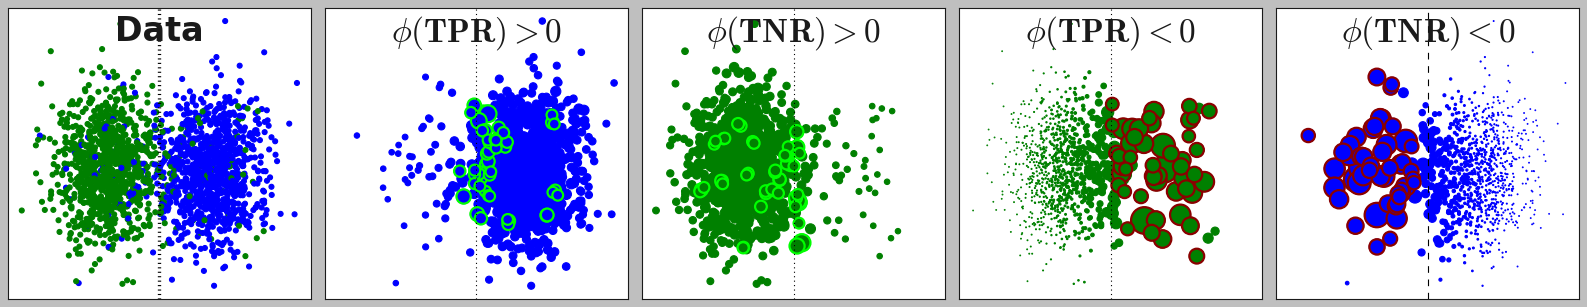

In [52]:
f = plt.figure(figsize=(20,4))
f.facecolor='white'
#plt.subplot(3,3,1)
ax1 = plt.subplot2grid((1, 5), (0, 0))
ax1.axvline(0, color='black', linewidth=3, linestyle=':')
ax1.set_title('Data', fontsize=30, y=1.0, pad=-30, fontweight="bold")
ax1.set_xticks([])
ax1.set_yticks([])
ax1.scatter(X_train[:,0], X_train[:,1], color = [cc(i) for i in y_train])


ax2 = plt.subplot2grid((1, 5), (0, 1))
ax2.axvline(0, color='black', linewidth=1, linestyle=':')
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title('$\mathbf{\phi(TPR)>0}$', fontsize=30, y=1.0, pad=-30, fontweight="bold")
size, edgecolor= get_size(fsv_b_synth.sv_tpr, True)
idx_max = np.argsort(size)[::-1][:50]
ax2.scatter(X_train[:,0], X_train[:,1], color = [cc(i) for i in y_train], s = size/5)
ax2.scatter(X_train[idx_max,0], X_train[idx_max,1], linewidth=2,\
            color = np.array([cc(i) for i in y_train])[idx_max], s = size[idx_max]/5, edgecolor=edgecolor)


ax3 = plt.subplot2grid((1, 5), (0, 2))
ax3.axvline(0, color='black', linewidth=1, linestyle=':')
ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_title('$\mathbf{\phi(TNR)>0}$', fontsize=30, y=1.0, pad=-30, fontweight="bold")
size, edgecolor= get_size(fsv_b_synth.sv_tnr, True)
idx_max = np.argsort(size)[::-1][:50]
ax3.scatter(X_train[:,0], X_train[:,1], color = [cc(i) for i in y_train], s = size/5)
ax3.scatter(X_train[idx_max,0], X_train[idx_max,1], linewidth=2,\
            color = np.array([cc(i) for i in y_train])[idx_max], s = size[idx_max]/5, edgecolor=edgecolor)



ax5 = plt.subplot2grid((1, 5), (0, 3))
ax5.axvline(0, color='black', linewidth=1, linestyle=':')
ax5.set_xticks([])
ax5.set_yticks([])
ax5.set_title('$\mathbf{\phi(TPR)<0}$', fontsize=30, y=1.0, pad=-30, fontweight="bold")
size, edgecolor= get_size(fsv_b_synth.sv_tpr, False)
idx_max = np.argsort(size)[::-1][:50]
ax5.scatter(X_train[:,0], X_train[:,1], color = [cc(i) for i in y_train], s = size/5)
ax5.scatter(X_train[idx_max,0], X_train[idx_max,1], linewidth=2,\
            color = np.array([cc(i) for i in y_train])[idx_max], s = size[idx_max]/5, edgecolor=edgecolor)


ax6 = plt.subplot2grid((1, 5), (0, 4))
ax6.axvline(0, color='black', linewidth=1, linestyle='--')
ax6.set_xticks([])
ax6.set_yticks([])
ax6.set_title('$\mathbf{\phi(TNR)<0}$', fontsize=30, y=1.0, pad=-30, fontweight="bold")
size, edgecolor= get_size(fsv_b_synth.sv_tnr, False)
idx_max = np.argsort(size)[::-1][:50]
ax6.scatter(X_train[:,0], X_train[:,1], color = [cc(i) for i in y_train], s = size/5)
ax6.scatter(X_train[idx_max,0], X_train[idx_max,1], linewidth=2,\
            color = np.array([cc(i) for i in y_train])[idx_max], s = size[idx_max]/5, edgecolor=edgecolor)


plt.tight_layout()
plt.savefig('figs/SV_plots/synth_bal/ScatterSVtpnrB.pdf', dpi=300, bbox_inches = 'tight', PAD_INCHES=0)
plt.show()



In [45]:
def percentage_increment(new,old):
    return ((old-new)/old)*100

In [46]:
percentage_increment(0.06,0.61)

90.16393442622952

```python
def scaler(array,max_l=20, min_l=1):
    array = array.copy()
    scaled = ((array-array.min())/(array.max()-array.min())) * (max_l-min_l)+ min_l
    desscaled = ((scaled-min_l)/(max_l-min_l)) * (array.max()-array.min()) + array.min()
    return scaled, desscaled, array
```


### Noisy example - Balanced Train & Test but 5% flip labels

In [47]:
del X_train, X_test, y_train, y_test

In [48]:
X_train, y_train = dt.make_blobs(n_samples=[1000,1000], centers=[[-1,0],[1,0]], 
                    cluster_std=(.5,.5), n_features=2, random_state=42)
y_train=np.array([1-l if np.random.rand()>0.95 else l for l in y_train ])
X_test, y_test = dt.make_blobs(n_samples=[200,200], centers=[[-1,0],[1,0]], 
                    cluster_std=(.5,.5), n_features=2, random_state=42)

Finding best k: 100%|█████████████████████████████████████████████████████████████████| 28/28 [00:00<00:00, 364.32it/s]


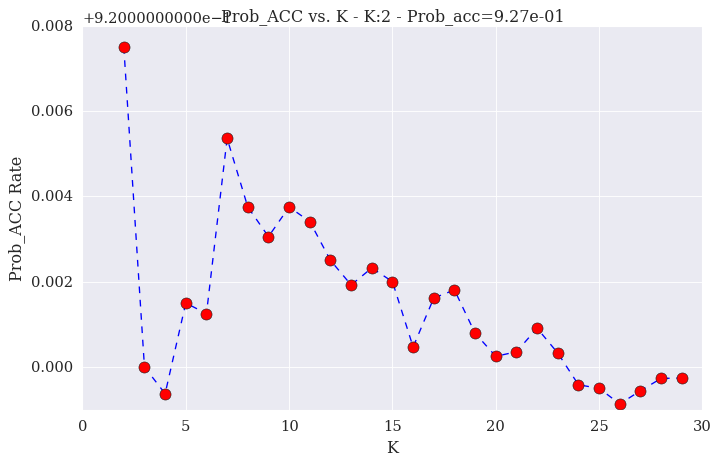

Best K: 2


Calculating SV Matrix: 100%|████████████████████████████████████████████████████████| 400/400 [00:01<00:00, 309.87it/s]


<Figure size 640x480 with 0 Axes>

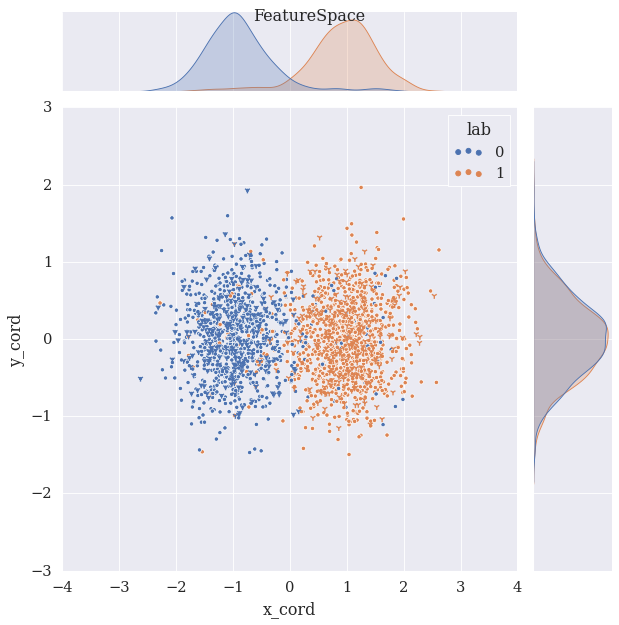

<Figure size 640x480 with 0 Axes>

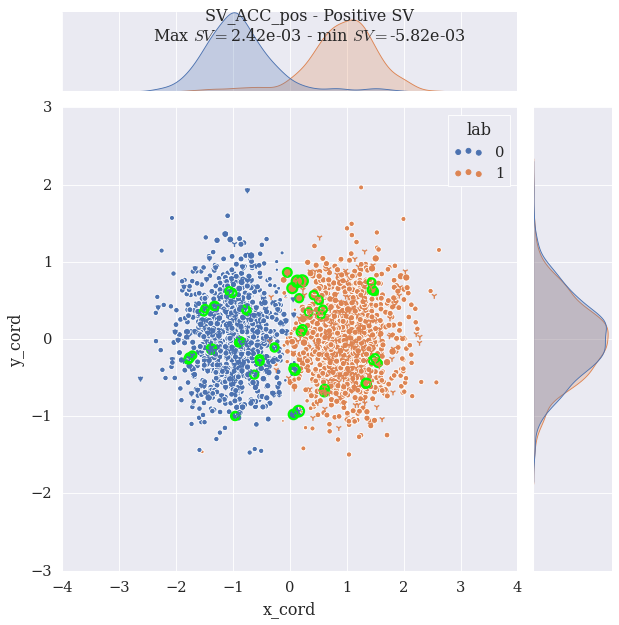

<Figure size 640x480 with 0 Axes>

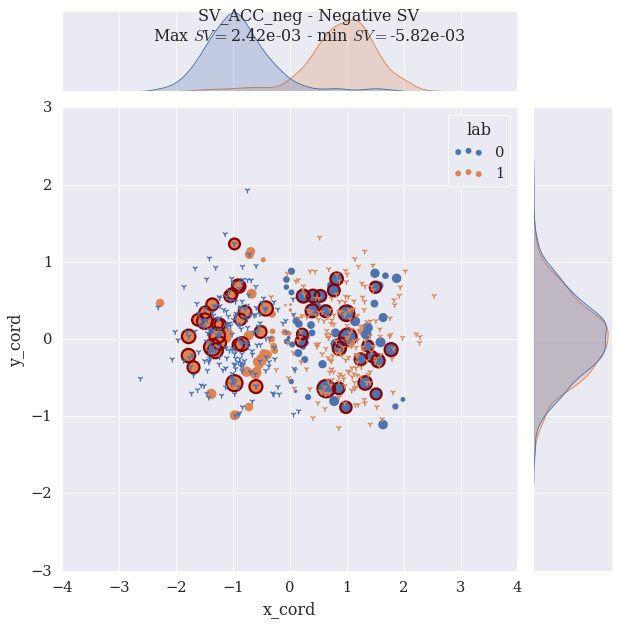

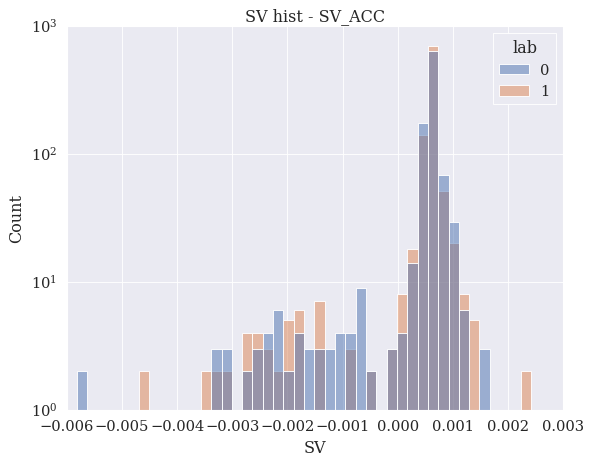

<Figure size 640x480 with 0 Axes>

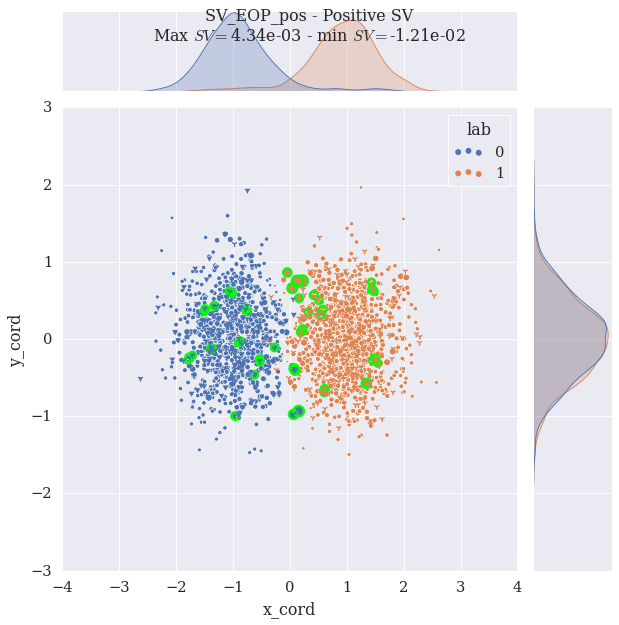

<Figure size 640x480 with 0 Axes>

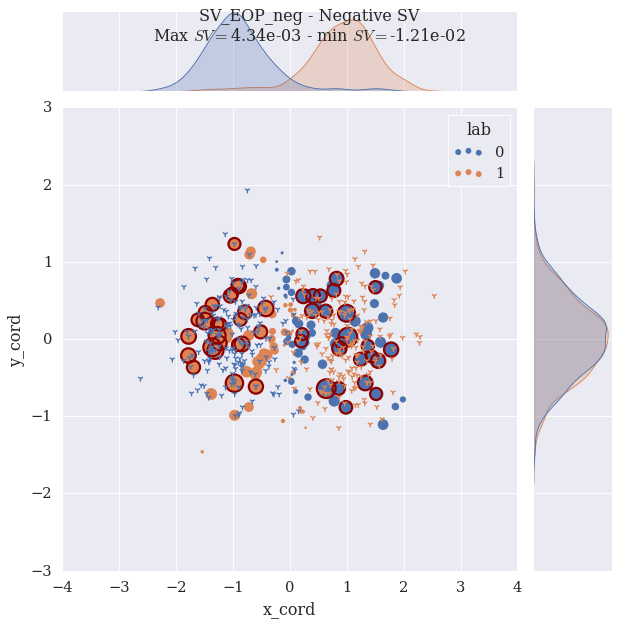

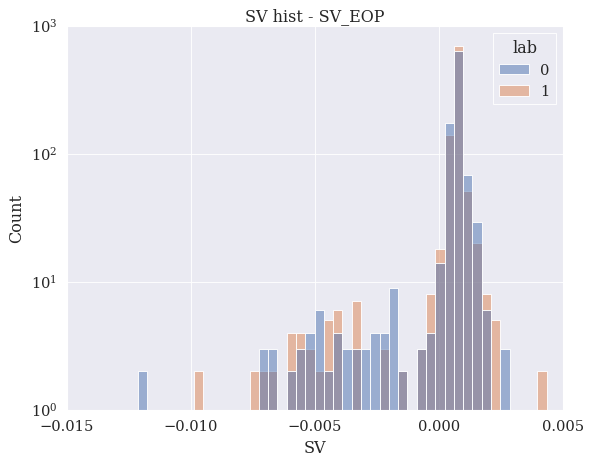

<Figure size 640x480 with 0 Axes>

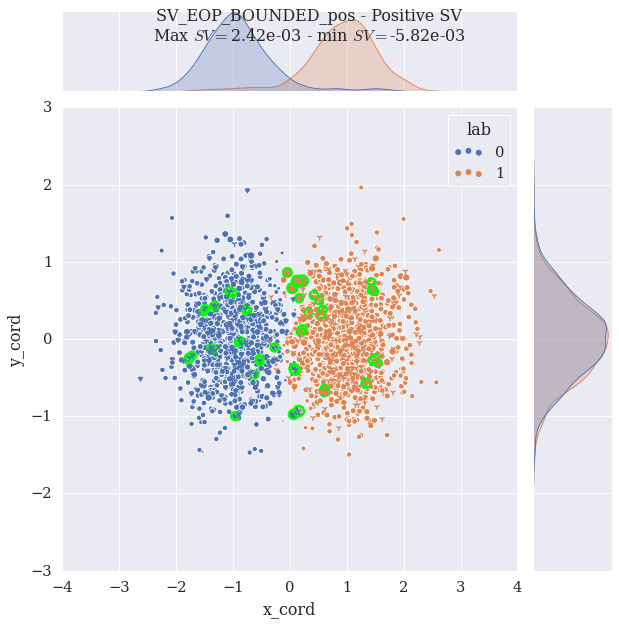

<Figure size 640x480 with 0 Axes>

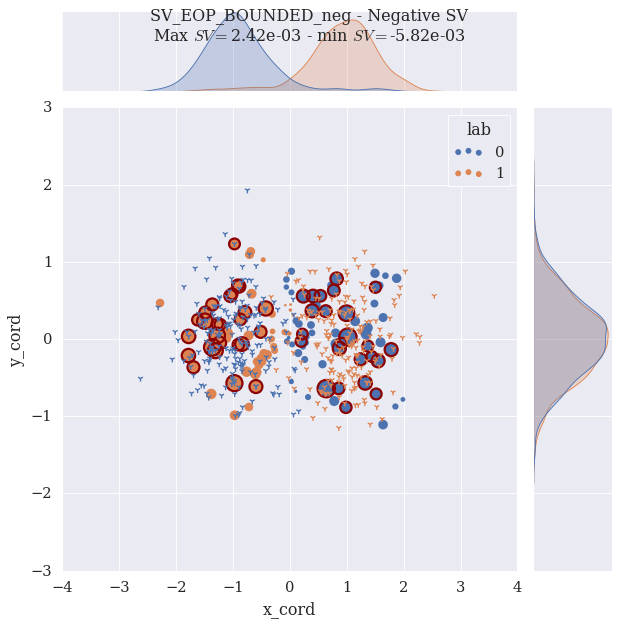

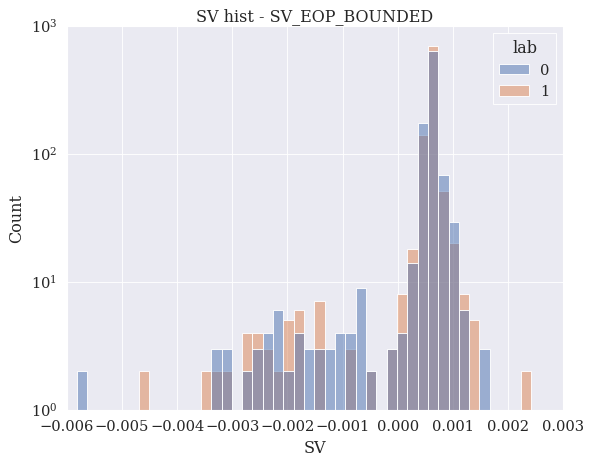

<Figure size 640x480 with 0 Axes>

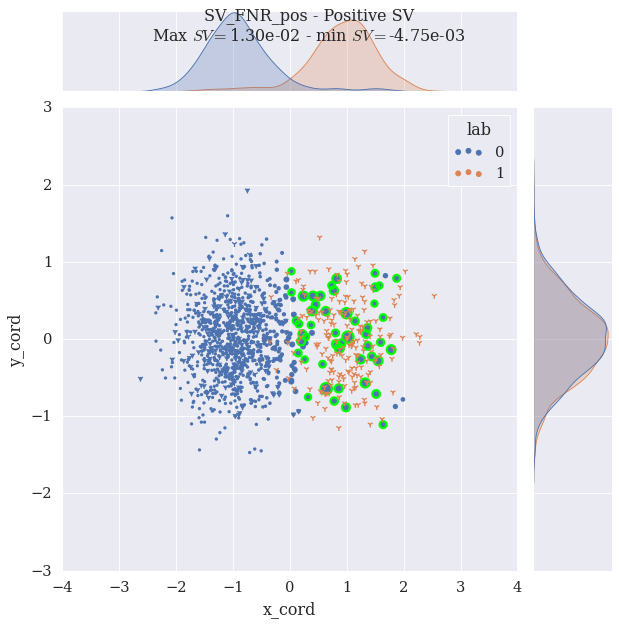

<Figure size 640x480 with 0 Axes>

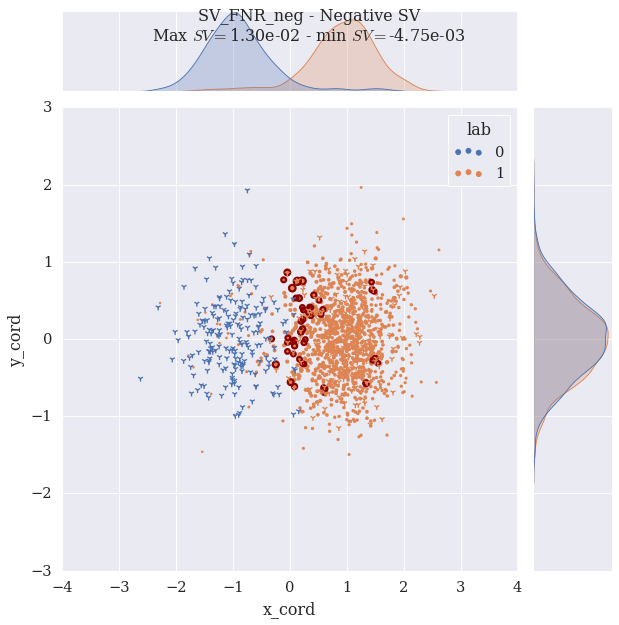

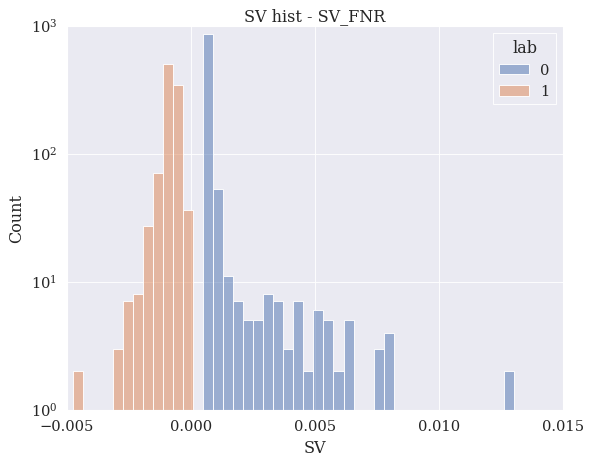

<Figure size 640x480 with 0 Axes>

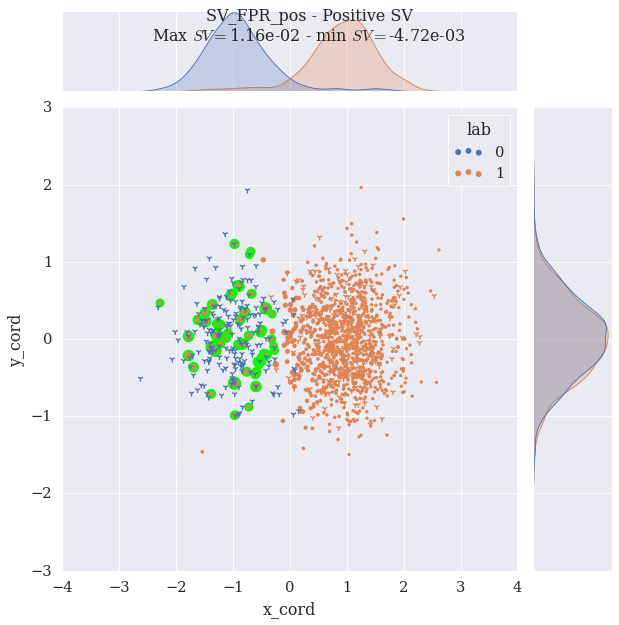

<Figure size 640x480 with 0 Axes>

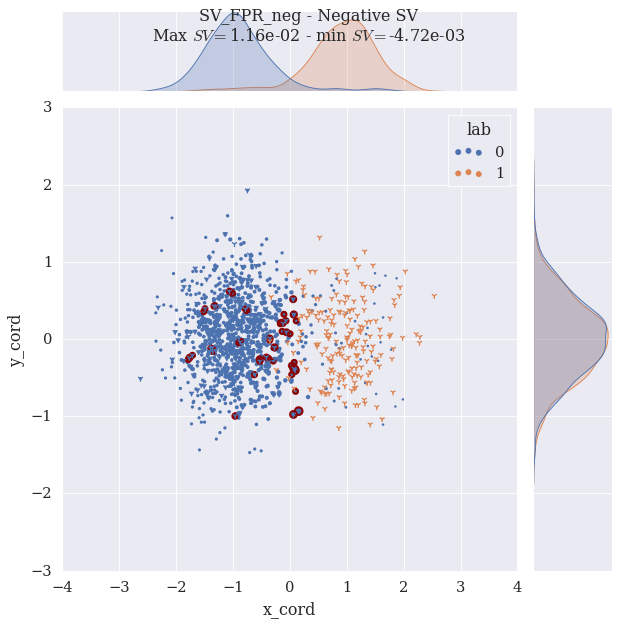

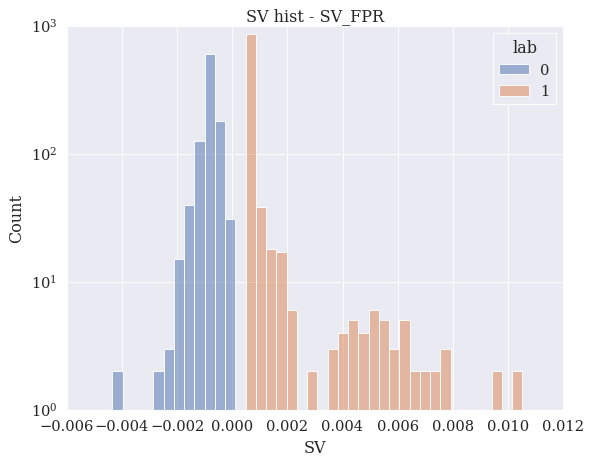

<Figure size 640x480 with 0 Axes>

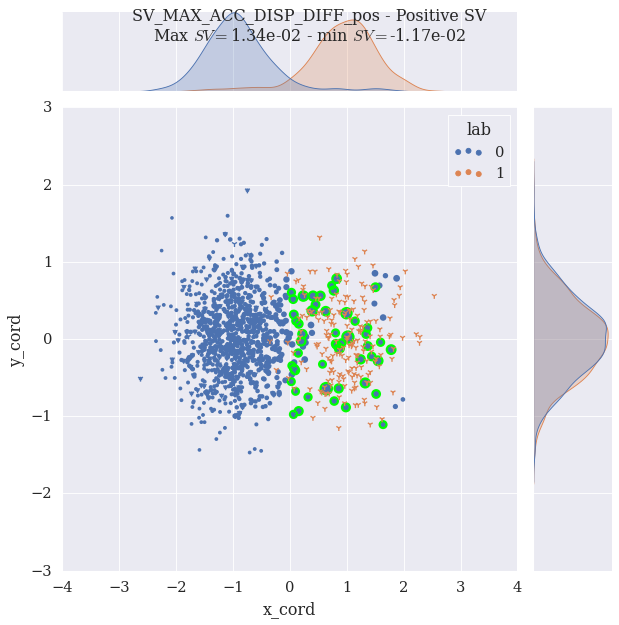

<Figure size 640x480 with 0 Axes>

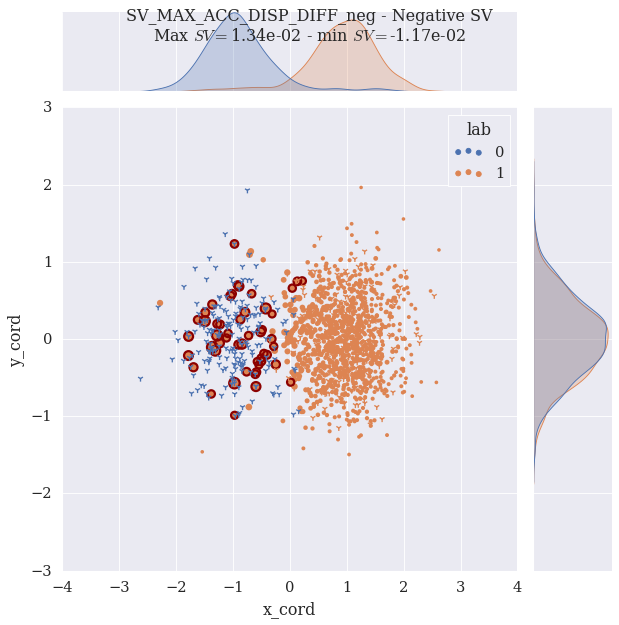

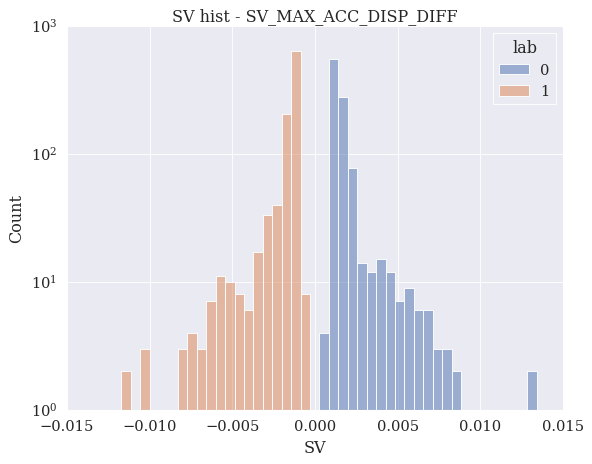

<Figure size 640x480 with 0 Axes>

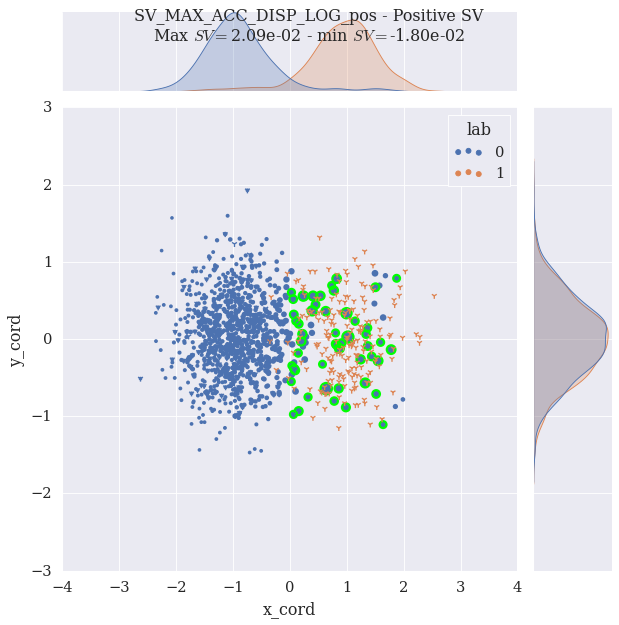

<Figure size 640x480 with 0 Axes>

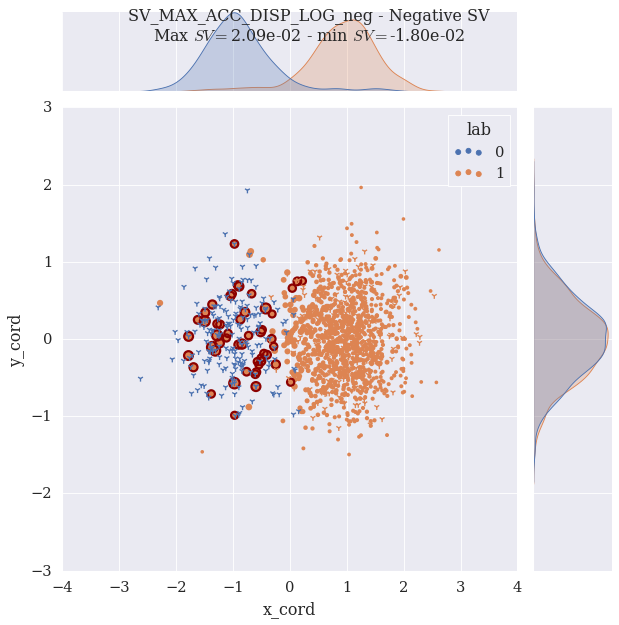

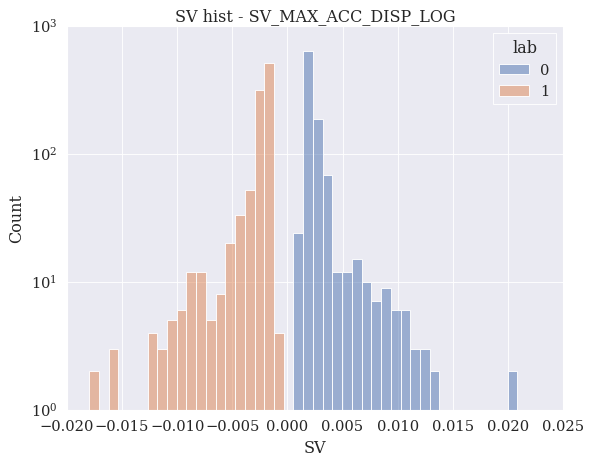

<Figure size 640x480 with 0 Axes>

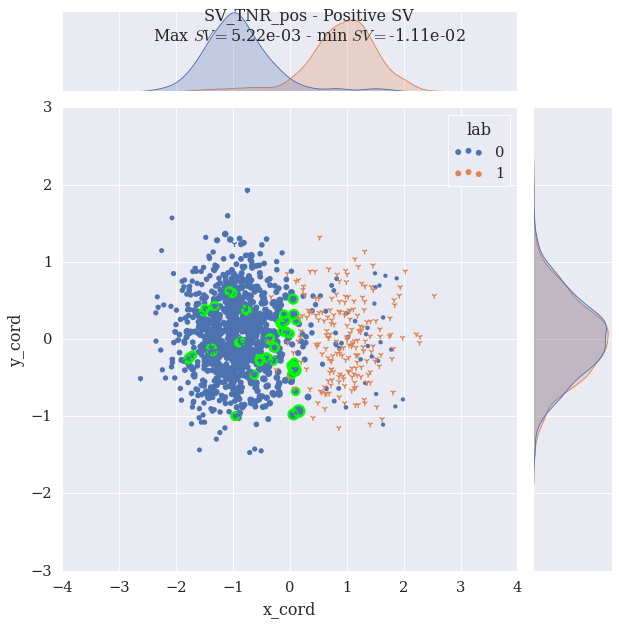

<Figure size 640x480 with 0 Axes>

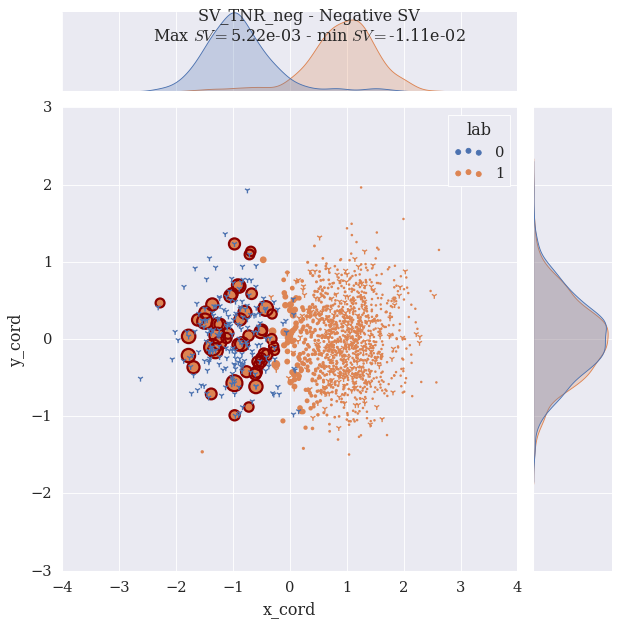

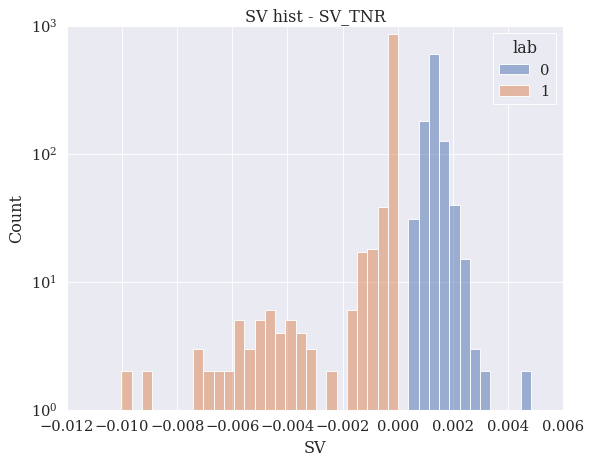

<Figure size 640x480 with 0 Axes>

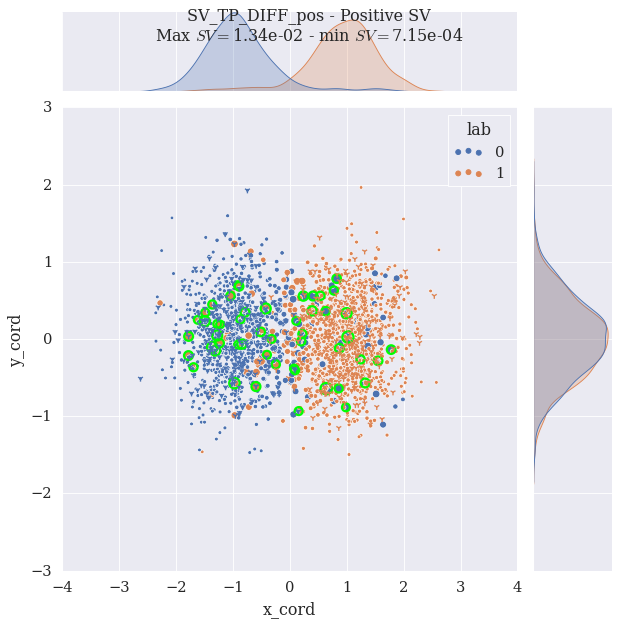

<Figure size 640x480 with 0 Axes>

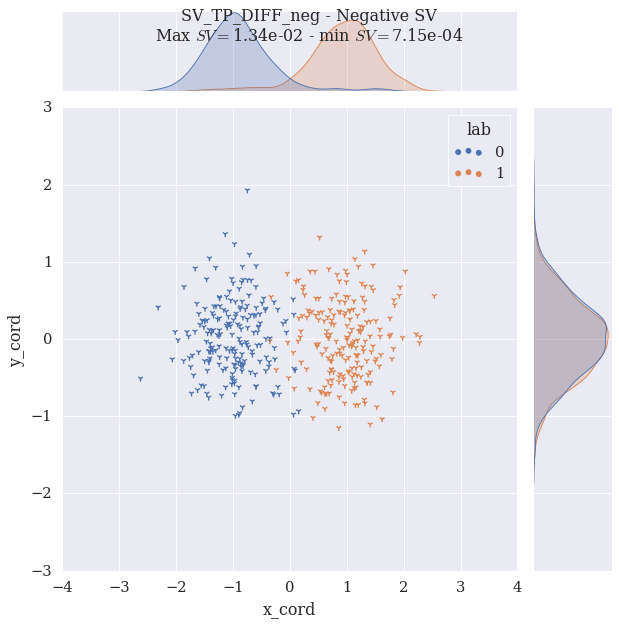

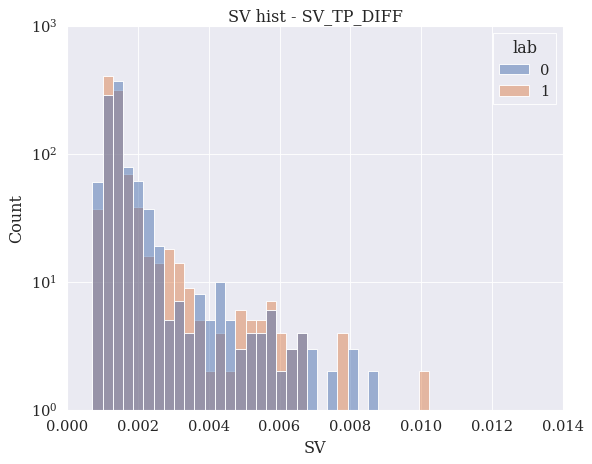

<Figure size 640x480 with 0 Axes>

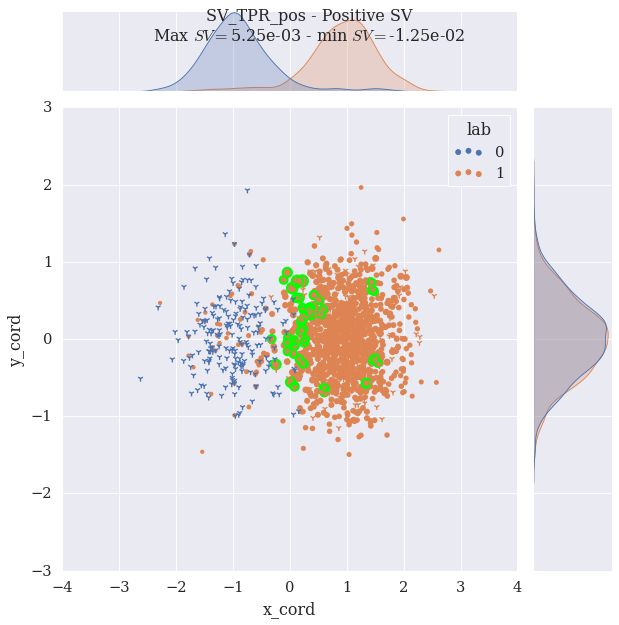

<Figure size 640x480 with 0 Axes>

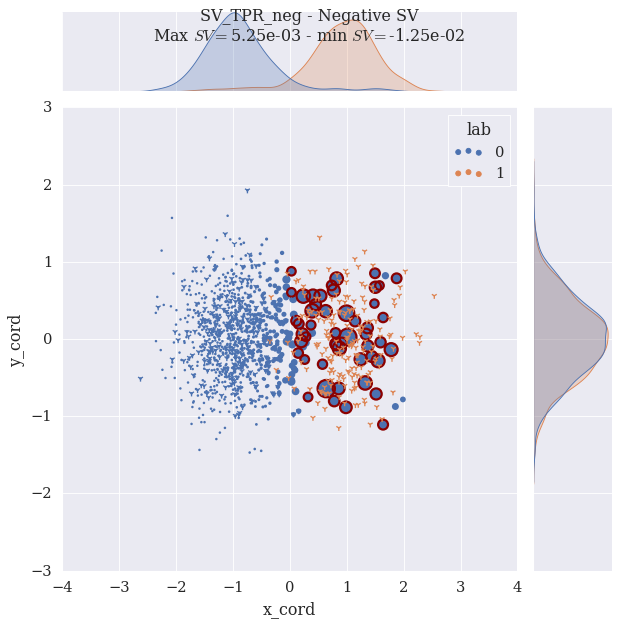

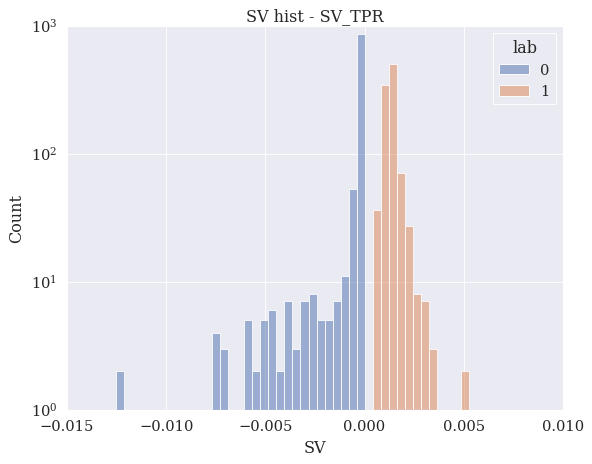

                           sum
sv_acc                0.927500
sv_eop                0.855000
sv_eop_bounded        0.927500
sv_fnr                0.080000
sv_fpr                0.065000
sv_max_acc_disp_diff  0.015000
sv_max_acc_disp_log   0.000067
sv_tnr                0.935000
sv_tp_diff            3.482047
sv_tpr                0.920000


,acc,TPR,TNR,FPR,FNR,EqualOp,EqualOp_bounded,Max_acc_disp_diff,Max_acc_disp_log,Max_acc_disp_ratio,AUC
def,0.9275,0.985,0.870,0.130,0.015,0.855,0.9275,0.115,0.179108,0.132184,0.983075
opt_0.50,0.9275,0.985,0.870,0.130,0.015,0.855,0.9275,0.115,0.179108,0.132184,0.983075
indep,0.9275,0.920,0.935,0.065,0.080,0.855,0.9275,0.015,0.023333,0.016304,0.983075


In [49]:
fsv_b_synth = FairShapley(X_train, y_train, X_test, y_test, save_folder=FOLDER_PLOTS+'synth_bal_noise/')
m = fsv_b_synth.whole_process(save=False, show_plot=True)
pd.DataFrame(m).T

### Unbalanced - Both train and test unbalanced

In [ ]:
del X_train, X_test, y_train, y_test

In [ ]:
X_train, y_train = dt.make_blobs(n_samples=[100,1000], centers=[[-1,0],[1,0]], 
                    cluster_std=(.8,.5), n_features=2, random_state=42)
X_test, y_test = dt.make_blobs(n_samples=[10,100], centers=[[-1,0],[1,0]], 
                    cluster_std=(.8,.5), n_features=2, random_state=42)


In [ ]:
fsv_ub_synth = FairShapley(X_train, y_train, X_test, y_test, save_folder=FOLDER_PLOTS+'synth_trUnbal_tstUnbal/')
m = fsv_ub_synth.whole_process(save=False)
pd.DataFrame(m).T

### Unbalanced - Balanced train - Unbalanced test

In [ ]:
del X_train, X_test, y_train, y_test

In [ ]:
X_train, y_train = dt.make_blobs(n_samples=[1000,1000], centers=[[-1,0],[1,0]], 
                    cluster_std=(.5,.5), n_features=2, random_state=42)
X_test, y_test = dt.make_blobs(n_samples=[10,100], centers=[[-1,0],[1,0]], 
                    cluster_std=(.8,.5), n_features=2, random_state=42)

In [ ]:
fsv_ub_synth = FairShapley(X_train, y_train, X_test, y_test, save_folder=FOLDER_PLOTS+'synth_trBal_tstUnbal/')
m = fsv_ub_synth.whole_process(save=True, show_plot=True)
pd.DataFrame(m).T

In [ ]:
plt.scatter(fsv_ub_synth.sv_acc, fsv_ub_synth.sv_eop)

### Unbalanced - Unbalanced Train - Balanced test

In [ ]:
del X_train, X_test, y_train, y_test

In [ ]:
X_train, y_train = dt.make_blobs(n_samples=[200,1000], centers=[[-1,0],[1,0]], 
                    cluster_std=(.5,.5), n_features=2, random_state=42)
X_test, y_test = dt.make_blobs(n_samples=[100,100], centers=[[-1,0],[1,0]], 
                    cluster_std=(.5,.5), n_features=2, random_state=42)

In [ ]:
fsv_ub_synth = FairShapley(X_train, y_train, X_test, y_test, save_folder=FOLDER_PLOTS+'synth_trUnbal_tstBal/')
metrics = fsv_ub_synth.whole_process(save=True, show_plot=True)
pd.DataFrame(metrics).T

In [ ]:
plt.figure(figsize=(12,12))


plt.subplot(3,3,1)
plt.axvline(0, color='black', linewidth=3, linestyle=':')
plt.title('Data', fontsize=30, y=1.0, pad=-30)
plt.xticks([])
plt.yticks([])
plt.scatter(X_train[:,0], X_train[:,1], color = [cc(i) for i in y_train])


plt.subplot(3,3,2)
plt.axvline(0, color='black', linewidth=1, linestyle=':')
plt.xticks([])
plt.yticks([])
plt.title('$\phi(TPR)>0$', fontsize=30, y=1.0, pad=-30)
size, edgecolor= get_size(fsv_ub_synth.sv_tpr, True)
idx_max = np.argsort(size)[::-1][:50]
plt.scatter(X_train[:,0], X_train[:,1], color = [cc(i) for i in y_train], s = size/5)
plt.scatter(X_train[idx_max,0], X_train[idx_max,1], linewidth=2,\
            color = np.array([cc(i) for i in y_train])[idx_max], s = size[idx_max]/5, edgecolor=edgecolor)


plt.subplot(3,3,3)
plt.axvline(0, color='black', linewidth=1, linestyle=':')
plt.xticks([])
plt.yticks([])
plt.title('$\phi(TNR)>0$', fontsize=30, y=1.0, pad=-30)
size, edgecolor= get_size(fsv_ub_synth.sv_tnr, True)
idx_max = np.argsort(size)[::-1][:50]
plt.scatter(X_train[:,0], X_train[:,1], color = [cc(i) for i in y_train], s = size/5)
plt.scatter(X_train[idx_max,0], X_train[idx_max,1], linewidth=2,\
            color = np.array([cc(i) for i in y_train])[idx_max], s = size[idx_max]/5, edgecolor=edgecolor)


plt.subplot(3,3,4)
plt.axvline(0, color='black', linewidth=1, linestyle=':')
plt.xticks([])
plt.yticks([])
plt.title('$\phi(Acc)$', fontsize=30, y=1.0, pad=-30)
size, edgecolor= get_size(fsv_ub_synth.sv_acc, True)
idx_max = np.argsort(size)[::-1][:50]
plt.scatter(X_train[:,0], X_train[:,1], color = [cc(i) for i in y_train], s = size/5)
plt.scatter(X_train[idx_max,0], X_train[idx_max,1], linewidth=2,\
            color = np.array([cc(i) for i in y_train])[idx_max], s = size[idx_max]/5, edgecolor=edgecolor)


plt.subplot(3,3,5)
plt.axvline(0, color='black', linewidth=1, linestyle=':')
plt.xticks([])
plt.yticks([])
plt.title('$\phi(TPR)<0$', fontsize=30, y=1.0, pad=-30)
size, edgecolor= get_size(fsv_ub_synth.sv_tpr, False)
idx_max = np.argsort(size)[::-1][:50]
plt.scatter(X_train[:,0], X_train[:,1], color = [cc(i) for i in y_train], s = size/5)
plt.scatter(X_train[idx_max,0], X_train[idx_max,1], linewidth=2,\
            color = np.array([cc(i) for i in y_train])[idx_max], s = size[idx_max]/5, edgecolor=edgecolor)




plt.subplot(3,3,6)
plt.axvline(0, color='black', linewidth=1, linestyle=':')
plt.xticks([])
plt.yticks([])
plt.title('$\phi(TNR)$<0', fontsize=30, y=1.0, pad=-30)
size, edgecolor= get_size(fsv_ub_synth.sv_tnr, False)
idx_max = np.argsort(size)[::-1][:50]
plt.scatter(X_train[:,0], X_train[:,1], color = [cc(i) for i in y_train], s = size/5)
plt.scatter(X_train[idx_max,0], X_train[idx_max,1], linewidth=2,\
            color = np.array([cc(i) for i in y_train])[idx_max], s = size[idx_max]/5, edgecolor=edgecolor)

plt.tight_layout()
plt.savefig('figs/SV_plots/synth_trUnbal_tstBal/ScatterSVTPNR_ub.pdf', bbox_inches = 'tight')
plt.show()




#frameon=False, projection='polar', facecolor='red'
#plt.scatter(X_train[idx_max,0], X_train[idx_max,1], marker='.', s=size[idx_max], facecolor="none", edgecolors=edgecolor, linewidth=2)

In [ ]:
y_train

In [ ]:
plt.scatter(fsv_ub_synth.sv_acc, fsv_ub_synth.sv_eop)

### Unbalanced 2

In [ ]:
X_train, y_train = dt.make_blobs(n_samples=[100,1000], centers=[[-0.5,0],[0.5,0]], 
                    cluster_std=(.8,.5), n_features=2, random_state=42)
X_test, y_test = dt.make_blobs(n_samples=[100,100], centers=[[-0.5,0],[0.5,0]], 
                    cluster_std=(.5,.5), n_features=2, random_state=42)

                    
fsv_ub_synth = FairShapley(X_train, y_train, X_test, y_test, save_folder=FOLDER_PLOTS+'synth_trUnbal_tstUnbal_2/')
metrics = fsv_ub_synth.whole_process(save=True, show_plot=True)
pd.DataFrame(metrics).T

In [ ]:
plt.scatter(fsv_ub_synth.sv_acc, fsv_ub_synth.sv_eop)

In [ ]:
import seaborn as sns

# Fairness example

**UTILS**

In [75]:
sns.set_theme(style="darkgrid", palette="deep", font='serif')
sns.set_context("paper", font_scale=1.5)
#plt.style.use('classic')

In [54]:
def disparate_impact(y_pred, A, vuln_g=0):
    ar_gv = np.mean(y_pred[A==vuln_g])
    ar_gp = np.mean(y_pred[A!=vuln_g])
    return ar_gv/ar_gp

def equal_op(y_true, y_pred, A, vuln_g=0):
    tpr_gv = np.mean(y_pred[np.logical_and(A==vuln_g, y_true==1)]) # good vulnerables accepted (Y,A,hat{Y})
    tpr_gp = np.mean(y_pred[np.logical_and(A!=vuln_g, y_true==1)]) # good privileged accepted
    return tpr_gv- tpr_gp
    

def equal_odds(y_true, y_pred, A, vuln_g=0):
    tpr_gv = np.mean(y_pred[np.logical_and(A==vuln_g, y_true==1)]) # good vulnerables accepted (Y,A,hat{Y})
    tpr_gp = np.mean(y_pred[np.logical_and(A!=vuln_g, y_true==1)]) # good privileged accepted
    
    fpr_gv = np.mean(y_pred[np.logical_and(A==vuln_g, y_true==0)]) # bad vulnerable accepted
    fpr_gp = np.mean(y_pred[np.logical_and(A!=vuln_g, y_true==0)]) # bad privileged accepted

    return 0.5* ((tpr_gv- tpr_gp)+(fpr_gv- fpr_gp))

def equal_odds_abs(y_true, y_pred, A, vuln_g=0):
    tpr_gv = np.mean(y_pred[np.logical_and(A==vuln_g, y_true==1)]) # good vulnerables accepted (Y,A,hat{Y})
    tpr_gp = np.mean(y_pred[np.logical_and(A!=vuln_g, y_true==1)]) # good privileged accepted
    
    fpr_gv = np.mean(y_pred[np.logical_and(A==vuln_g, y_true==0)]) # bad vulnerable accepted
    fpr_gp = np.mean(y_pred[np.logical_and(A!=vuln_g, y_true==0)]) # bad privileged accepted

    return 0.5* (np.abs(tpr_gv-tpr_gp)+np.abs(fpr_gv-fpr_gp))

def FPR_diff(y_true, y_pred, A, vuln_g=0):    
    fpr_gv = np.mean(y_pred[np.logical_and(A==vuln_g, y_true==0)]) # bad vulnerable accepted
    fpr_gp = np.mean(y_pred[np.logical_and(A!=vuln_g, y_true==0)]) # bad privileged accepted

    return fpr_gv- fpr_gp

def FNR_diff(y_true, y_pred, A, vuln_g=0):    
    tpr_gv = np.mean(y_pred[np.logical_and(A==vuln_g, y_true==1)]) # good vulnerables accepted (Y,A,hat{Y})
    tpr_gp = np.mean(y_pred[np.logical_and(A!=vuln_g, y_true==1)]) # good privileged accepted
    
    fnr_gv = 1 - tpr_gv # good vulnerable rejected
    fnr_gp = 1 - tpr_gp # good privileged redejcted

    return fnr_gv- fnr_gp

def print_metrics(model, X_tst, y_tst, A_tst, print_met = True, return_met = False):
    y_pred = model.predict(X_tst)
    acc = np.mean(y_pred==y_tst)
    
    fpr_diff = FPR_diff(y_tst, y_pred, A_tst)
    fnr_diff = FNR_diff(y_tst, y_pred, A_tst)
    
    di = disparate_impact(y_pred, A_tst)
    eop = equal_op(y_tst, y_pred, A_tst)
    eods1 = equal_odds(y_tst, y_pred, A_tst)
    eods2 = equal_odds_abs(y_tst, y_pred, A_tst)

    if print_met:
        print(f"""
        Accuracy:\t\t{acc:.4f}

        D_FPR: \t\t{fpr_diff:.4f}
        D_FNR: \t\t{fnr_diff:.4f}  

        DI ratio:\t\t{di:.4f}
        Eq. Op diff:\t{eop:.4f}
        Eq. Ods diff:\t{eods1:.4f}
        Avg. Eq. Ods:\t{eods2:.4f}
        """)
        
    if return_met:
        metrics_dict = metrics_dict = {
        'Accuracy': acc,
        'D_FPR': fpr_diff,
        'D_FNR': fnr_diff,
        'DIratio': di,
        'EqOpDiff': eop,
        'EqOddsDiff': eods1,
        'Avg. Eq. Ods': eods2}
        return metrics_dict


In [55]:
from sklearn.linear_model import LogisticRegression
def print_scatter(X, y, A, vuln=0,
                  boundary=False, size=None, weights=None,
                  X_tst=None, y_tst=None, A_tst=None,
                  highlight=False, top_k=10,
                  plt_legend=True,title=None, axis_off=True,
                  ret_figure=False):
    palette = sns.color_palette("tab10", 2)
    palette = ['red','green']
    f, ax = plt.subplots(1,1, figsize=(5,4))
    
    if boundary:
        if weights is None:
            weights = [1]*X.shape[0]
        else:
            #weights[weights<0]=0
            weights = (weights-np.min(weights))/(np.max(weights)-np.min(weights))
            #weights = np.log(weights+1)
            weights = (weights / np.sum(weights))*len(weights)
        
        clf = LogisticRegression(random_state=42)
        #clf = GradientBoostingClassifier(random_state=42)# make_pipeline(StandardScaler(), GradientBoostingClassifier())
        clf.fit(X, y, sample_weight = weights)
        #cm = plt.cm.RdBu
        #cm = ListedColormap(["#FF0000", "#0000FF"])
        colors = [palette[0], palette[1]]
        #colors = [(1,0,0), (0,1,0)]
        cm = LinearSegmentedColormap.from_list(
                "Custom", colors, N=10)
        DecisionBoundaryDisplay.from_estimator(
            clf, X, cmap=cm, alpha=0.2, ax=ax, eps=0.1,
            response_method="predict")
        
        assert X_tst is not None, "X_tst cannot be None"
        assert y_tst is not None, "y_tst cannot be None"
        assert A_tst is not None, "A_tst cannot be None"
        
        result = print_metrics(clf, X_tst, y_tst, A_tst,
                               print_met = False, return_met = True)
        text = f"""Acc: {result['Accuracy']:.2f}\nDI: {result['DIratio']:.2f}"""
        text += f"""\nEOp: {result['EqOpDiff']:.2f}\nEOdds: {result['EqOddsDiff']:.2f}"""
        bbox_props = dict(boxstyle='square', facecolor='white', edgecolor='black', alpha=0.6)
        #plt.text(0.02, 0.98, text, ha='left', va='top', transform=ax.transAxes, bbox=bbox_props, weight='bold')
        plt.text(0.98, 0.02, text, ha='right', va='bottom', transform=ax.transAxes, bbox=bbox_props, weight='bold')
        
    
    
    for cl in np.unique(y):
        
        f_priv = (y==cl) & (A!=vuln)
        f_vuln = (y==cl) & (A==vuln)
        
        if size is None:
            s1=40
            s2=100
        else:
            s1 = size[f_priv]
            s2 = size[f_vuln]
            
        plt.scatter(X[f_priv ,0], X[f_priv,1], alpha = 1,
                    marker = "^", label=f"Y={int(cl)}, A=1",
                    s=s1,
                    color=palette[int(cl)])

        
        plt.scatter(X[f_vuln, 0], X[f_vuln, 1], alpha = 1,
                    marker = "+", label=f"Y={int(cl)}, A=0",
                    s=s2,
                    color=palette[int(cl)])
        
    if highlight:
        idx_ordered = np.argsort(weights)[::-1]
        X_o = X.copy()[idx_ordered][:top_k]
        A_o = A.copy()[idx_ordered][:top_k]
        y_o = y.copy()[idx_ordered][:top_k]
        s_o = size.copy()[idx_ordered][:top_k]
        
        for cl in np.unique(y):
            f_priv = (y_o==cl) & (A_o!=vuln)
            f_vuln = (y_o==cl) & (A_o==vuln)
            
            plt.scatter(X_o[f_priv ,0], X_o[f_priv,1], alpha = 1,
                        marker = "^",
                        s=s_o[f_priv],
                        color=palette[int(cl)], facecolor="none", edgecolors='lime', linewidth=1.5, zorder=10)

        
            plt.scatter(X_o[f_vuln, 0], X_o[f_vuln, 1], alpha = 1,
                        marker = "P",
                        s=s_o[f_vuln],
                        color=palette[int(cl)], edgecolors='lime', linewidth=1.5, zorder=10)
     
    if title:
        plt.title(title)
        
    if plt_legend:    
        lg = plt.legend(loc='upper left')
        for lh in lg.legendHandles:
            lh.set_sizes([45])
        
    if axis_off: 
        ax.grid(True)
        ax.set_xticklabels([])
        ax.set_yticklabels([])

    plt.tight_layout()
    plt.show()
    
    if boundary and ret_figure:
        return clf, f
    elif ret_figure:
        return f
    elif boundary:
        return clf

## Create Synthetic data

**Data from Zafar et al**

Fairness Beyond Disparate Treatment & Disparate Impact: Learning Classification without Disparate Mistreatment Muhammad Bilal Zafar, Isabel Valera, Manuel Gomez Rodriguez, Krishna P. Gummadi. https://arxiv.org/pdf/1610.08452.pdf

$$
p(x|z = 0, y = 1) = N ([2, 0], [5, 1; 1, 5])
$$
$$
p(x|z = 1, y = 1) = N ([2, 3], [5, 1; 1, 5])
$$
$$
p(x|z = 0, y = 0) = N ([−1, −3], [5, 1; 1, 5])
$$
$$
p(x|z = 1, y = 0) = N ([−1, 0], [5, 1; 1, 5])
$$

**Case 1**

In [56]:
n_per_class_priv = 100
n_per_class_unpriv = 100

np.random.seed(43)
X_a0y1 = multivariate_normal(mean = [2,0],   cov = [[5,1],[1,5]]).rvs(n_per_class_unpriv)
X_a1y1  = multivariate_normal(mean = [2,3],   cov = [[5,1],[1,5]]).rvs(n_per_class_priv)
X_a0y0  = multivariate_normal(mean = [-1,-3], cov = [[5,1],[1,5]]).rvs(n_per_class_unpriv)
X_a1y0  = multivariate_normal(mean = [-1,0],  cov = [[5,1],[1,5]]).rvs(n_per_class_priv)

X = np.vstack([X_a0y1,X_a1y1,X_a0y0,X_a1y0])

A = np.hstack([np.zeros(n_per_class_unpriv), np.ones(n_per_class_priv), np.zeros(n_per_class_unpriv), np.ones(n_per_class_priv)])
y = np.hstack([np.ones(n_per_class_unpriv), np.ones(n_per_class_priv), np.zeros(n_per_class_unpriv), np.zeros(n_per_class_priv)])


perm = np.arange(len(X), dtype=int)
np.random.shuffle(perm)
A = A[perm]
X = X[perm]
y = y[perm]

X.shape, A.shape, y.shape

((400, 2), (400,), (400,))

**Case 2**

**Data from Denis et al**

Christophe Denis, Romuald Elie, Mohamed Hebiri, François Hu. Fairness guarantee in multi-class classification. 2023. ffhal-03355938v3f https://hal.science/hal-03355938v3

## Data summarization and split

In [57]:
df = pd.DataFrame(X)
df['Y'] = y
df['A'] = A
df[['Y', 'A']].value_counts(normalize=True),\
df[['Y','A']].value_counts(normalize=False)

(Y    A  
 0.0  0.0    0.25
      1.0    0.25
 1.0  0.0    0.25
      1.0    0.25
 dtype: float64,
 Y    A  
 0.0  0.0    100
      1.0    100
 1.0  0.0    100
      1.0    100
 dtype: int64)

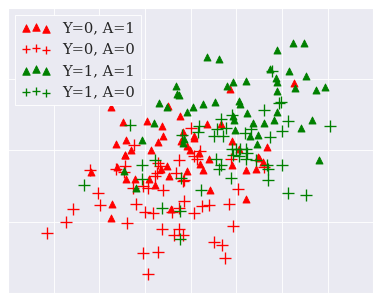

In [70]:
#print_scatter(X, y, A, vuln=0)
f = print_scatter(X[:200], y[:200], A[:200], vuln=0)

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
X_tr, X_vl, y_tr, y_vl, A_tr, A_vl = train_test_split(X, y, A, test_size=0.3, 
                          stratify=np.hstack([A.reshape(-1,1),y.reshape(-1,1)]), 
                          shuffle=True,
                          random_state=42)

X_vl, X_tst, y_vl, y_tst, A_vl, A_tst = train_test_split(X_vl, y_vl, A_vl, test_size=0.3, 
                          stratify=np.hstack([A_vl.reshape(-1,1),y_vl.reshape(-1,1)]), 
                          shuffle=True,
                          random_state=42)

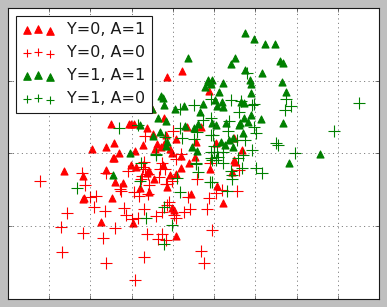

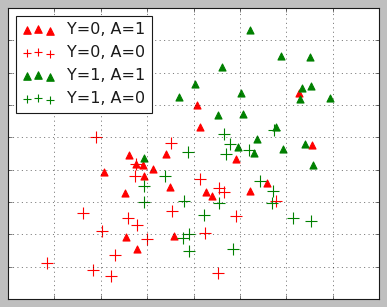

In [61]:
print_scatter(X_tr, y_tr, A_tr)
print_scatter(X_vl, y_vl, A_vl)

## Calculate SV with latent and histogram plots

In [62]:
protected_attributes_dict = {'values': A_vl,
                             'privileged_protected_attribute': 1,
                             'unprivileged_protected_attribute': 0,
                             'favorable_label':1,
                             'unfavorable_label':0
                            }    

fair_sv_extractor = FairShapley(X_tr, y_tr.astype(int), X_vl, y_vl.astype(int),
                    protected_attributes_dict = protected_attributes_dict,
                    show_plot=False, calculate_2dim=False)

k,prob_acc,probs=fair_sv_extractor.get_best_K()
SV_m = fair_sv_extractor.get_SV_matrix(K=20)
fair_sv_extractor.get_sv_arrays()
k

Calculating SV Matrix: 100%|█████████████████████████████████████████████████████████| 84/84 [00:00<00:00, 2141.42it/s]


5

In [63]:
df = pd.DataFrame(X_tr)
df['Y'] = y_tr
df['A'] = A_tr
df['SVAcc'] = fair_sv_extractor.sv_acc 
df['SVEOp'] = fair_sv_extractor.sv_equal_opportunity_difference
df['SVEOdds'] = fair_sv_extractor.sv_average_odds_difference
df['SVEOdds2'] = fair_sv_extractor.sv_average_absoulte_odds_difference

In [64]:
df['A'] = df['A'].map({1:'Priv', 0:'Vuln'})
df['Y'] = df['Y'].map({1:'Fav', 0:'Unfav'})

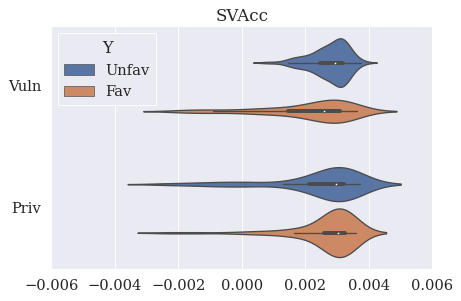

In [65]:
plt.figure(figsize=(6,4))
sns.violinplot(data=df, x='SVAcc', y= 'A',
               hue='Y',
               pallete={'Unfav':'r','Fav':'g'}).set_title('SVAcc', fontsize=15) #“layer”, “dodge”, “stack”, “fill”
plt.ylabel('')
plt.xlabel('')
plt.tight_layout()
#plt.savefig('figs/'+'hist_'+dataset_used+'_'+'gender_'+filename+'.pdf')
plt.show()

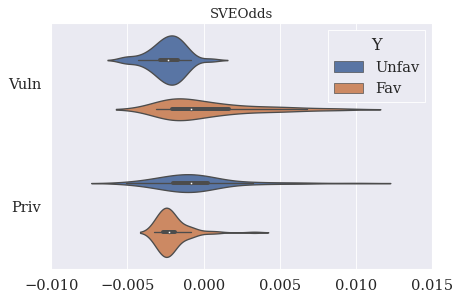

In [66]:
plt.figure(figsize=(6,4))
sns.violinplot(data=df, x='SVEOdds', y= 'A', hue='Y').set_title('SVEOdds', fontsize=12) #“layer”, “dodge”, “stack”, “fill”
plt.ylabel('')
plt.xlabel('')
plt.tight_layout()
#plt.savefig('figs/'+'hist_'+dataset_used+'_'+'gender_'+filename+'.pdf')
plt.show()

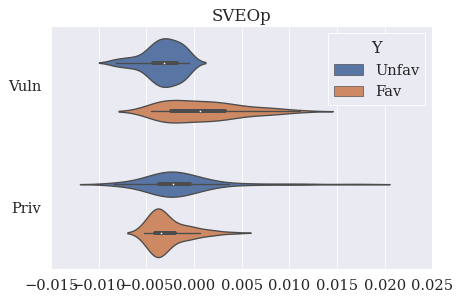

In [67]:
plt.figure(figsize=(6,4))
sns.violinplot(data=df, x='SVEOp', y= 'A', hue='Y').set_title('SVEOp', fontsize=15) #“layer”, “dodge”, “stack”, “fill”
plt.ylabel('')
plt.xlabel('')
plt.tight_layout()
#plt.savefig('figs/'+'hist_'+dataset_used+'_'+'gender_'+filename+'.pdf')
plt.show()

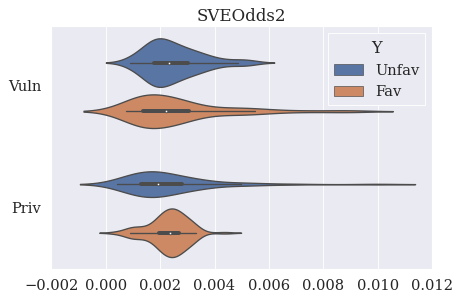

In [68]:
plt.figure(figsize=(6,4))
sns.violinplot(data=df, x='SVEOdds2', y= 'A', hue='Y').set_title('SVEOdds2', fontsize=15) #“layer”, “dodge”, “stack”, “fill”
plt.ylabel('')
plt.xlabel('')
plt.tight_layout()
#plt.savefig('figs/'+'hist_'+dataset_used+'_'+'gender_'+filename+'.pdf')
plt.show()

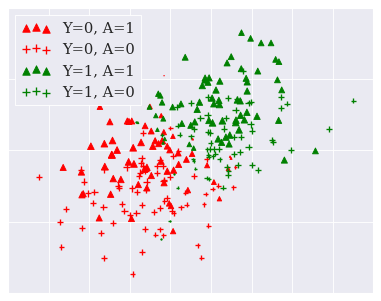

In [69]:
print_scatter(X_tr, y_tr, A_tr, size=df['SVAcc']*10000)

## Decission Boundary

In [81]:
sns.set_theme(style="darkgrid", palette="deep", font='serif')
sns.set_context("paper", font_scale=1.5)

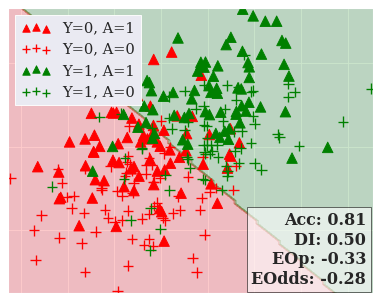


        Accuracy:		0.8056

        D_FPR: 		-0.2222
        D_FNR: 		0.3333  

        DI ratio:		0.5000
        Eq. Op diff:	-0.3333
        Eq. Ods diff:	-0.2778
        Avg. Eq. Ods:	0.2778
        


In [82]:
clf,f = print_scatter(X_tr, y_tr, A_tr, vuln=0,
             boundary = True, size=np.array([90]*len(X_tr)), ret_figure=True, #title='Original',
                     X_tst=X_tst, y_tst=y_tst, A_tst = A_tst)
print_metrics(clf, X_tst, y_tst, A_tst)

In [83]:
f.savefig(FOLDER_PLOTS+'/fairness/Case1Original.pdf', 
          dpi=300, format='pdf',facecolor='w', edgecolor='w', transparent=False, bbox_inches='tight', pad_inches = 0)


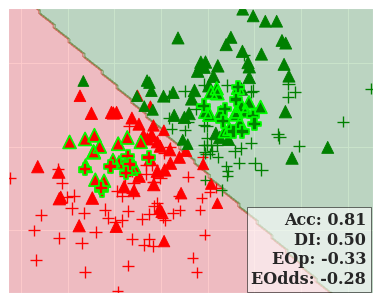


        Accuracy:		0.8056

        D_FPR: 		-0.2222
        D_FNR: 		0.3333  

        DI ratio:		0.5000
        Eq. Op diff:	-0.3333
        Eq. Ods diff:	-0.2778
        Avg. Eq. Ods:	0.2778
        


In [84]:
s = fair_sv_extractor.sv_acc.copy()
s = (s-np.min(s))/(np.max(s)-np.min(s))
s = (s / np.sum(s))*len(s)
s = np.exp(s)
s[np.argsort(s)[:40]]=0

clf, f = print_scatter(X_tr, y_tr, A_tr, vuln=0, size = s*40,
                     boundary = True,
                     weights=fair_sv_extractor.sv_acc, plt_legend=False, highlight=True, top_k=50, 
                     ret_figure=True, #title='$\phi(Acc)$'
                      X_tst=X_tst, y_tst=y_tst, A_tst = A_tst)
print_metrics(clf, X_tst, y_tst, A_tst)

In [85]:
f.savefig(FOLDER_PLOTS+'/fairness/Case1Acc.pdf', 
          dpi=300, format='pdf',facecolor='w', edgecolor='w', transparent=False, bbox_inches='tight', pad_inches = 0)

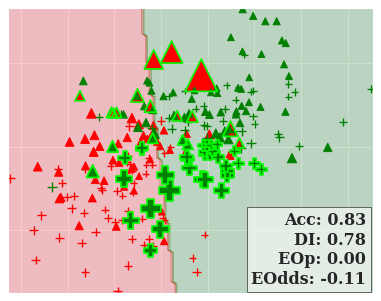


        Accuracy:		0.8333

        D_FPR: 		-0.2222
        D_FNR: 		0.0000  

        DI ratio:		0.7778
        Eq. Op diff:	0.0000
        Eq. Ods diff:	-0.1111
        Avg. Eq. Ods:	0.1111
        


In [86]:
s = fair_sv_extractor.sv_equal_opportunity_difference.copy()
s = (s-np.min(s))/(np.max(s)-np.min(s))
s = (s / np.sum(s))*len(s)
s = np.exp(s)
s[np.argsort(s)[:40]]=0


clf,f = print_scatter(X_tr, y_tr, A_tr, vuln=0, size = s*20,
             boundary = True,
             weights=fair_sv_extractor.sv_equal_opportunity_difference, plt_legend=False, highlight=True, top_k=50,
                   ret_figure=True, #title='$\phi(EOp)$',
                     X_tst=X_tst, y_tst=y_tst, A_tst = A_tst)
print_metrics(clf, X_tst, y_tst, A_tst)

In [87]:
f.savefig(FOLDER_PLOTS+'/fairness/Case1EOp.pdf', 
          dpi=300, format='pdf',facecolor='w', edgecolor='w', transparent=False, bbox_inches='tight', pad_inches = 0)

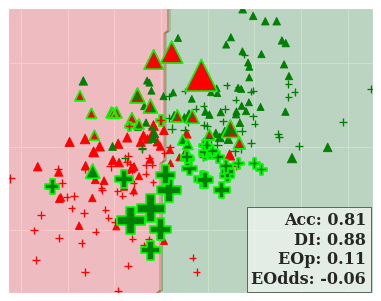


        Accuracy:		0.8056

        D_FPR: 		-0.2222
        D_FNR: 		-0.1111  

        DI ratio:		0.8750
        Eq. Op diff:	0.1111
        Eq. Ods diff:	-0.0556
        Avg. Eq. Ods:	0.1667
        


In [88]:
s = fair_sv_extractor.sv_average_odds_difference.copy()
s = (s-np.min(s))/(np.max(s)-np.min(s))
s = (s / np.sum(s))*len(s)
s= np.exp(s)
s[np.argsort(s)[:40]]=0

clf,f = print_scatter(X_tr, y_tr, A_tr, vuln=0, size = s*20, 
                      boundary = True, weights=fair_sv_extractor.sv_average_odds_difference,
                      plt_legend=False, ret_figure=True, #title='$\phi(EOdds)$',
                      highlight=True, top_k=50,
                      X_tst=X_tst, y_tst=y_tst, A_tst = A_tst)
print_metrics(clf, X_tst, y_tst, A_tst)

In [89]:
f.savefig(FOLDER_PLOTS+'/fairness/Case1EOdds.pdf', 
          dpi=300, format='pdf',facecolor='w', edgecolor='w', transparent=False, bbox_inches='tight', pad_inches = 0)

**Histograms**

In [ ]:
import matplotlib as mpl

In [ ]:
def gradient_hist(SVs, title):
    bns = int(np.sqrt(SVs.shape[0]))+70

    fig, ax = plt.subplots(figsize=(5,3))
    cm = plt.cm.get_cmap('seismic')
    n, bins, patches = plt.hist(SVs, 
                                bins = bns,
                                edgecolor='grey', linewidth=0.5)

    norm = mpl.colors.Normalize(vmin=SVs.min(), vmax=SVs.max())
    for c, p in zip(bins, patches):
        plt.setp(p, 'facecolor', cm(norm(c)))
    sm = plt.cm.ScalarMappable(cmap="seismic", norm=plt.Normalize(vmin=SVs.min(), vmax=SVs.max()))
        #sm.set_array([])
    cbar = plt.colorbar(sm)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
gradient_hist(df['SVAcc'], '$\phi_i(Acc)$')
gradient_hist(df['SVEOp'], '$\phi_i(EOp)$')
gradient_hist(df['SVEOdds'], '$\phi_i(EOdds)$')
gradient_hist(fair_sv_extractor.sv_tpr, '$\phi_i(TPR)$')
gradient_hist(fair_sv_extractor.sv_tpr_u, '$\phi_i(TPR_u)$')